# 1. Import required libraries

In [38]:
# numpy for numerical computations and array handling
import numpy as np
# PIL for loading and manipulating images
from PIL import Image
# matplotlib for plotting and visualizations
import matplotlib.pyplot as plt
# entropy for KL divergence and multivariate_normal for Gaussian modeling
from scipy.stats import entropy, multivariate_normal
# determinant and inverse functions for covariance matrix operations
from scipy.linalg import det, inv

# 2. Loading images
In this cell I'm loading the main image along with the three color patches (red, blue, yellow) that will be used for statistical comparisons and histogram analysis.

In [39]:
# loading the full original image
img_full = Image.open("image.png")
# loading the red patch extracted from the image
patch_red = Image.open("image_red_part.png")
# loading the blue patch extracted from the image
patch_blue = Image.open("image_blue_part.png")
# loading the yellow patch extracted from the image
patch_yellow = Image.open("image_yellow_part.png")

# 3. Converting images to grayscale
I'm converting the full image and all three color patches to grayscale and storing them as float32 NumPy arrays for further statistical analysis.

In [40]:
# converting the full image to grayscale and turning it into a float32 numpy array
img_full_gray = np.array(img_full.convert("L"), dtype=np.float32)
# converting the red patch to grayscale and turning it into a float32 numpy array
patch_red_gray = np.array(patch_red.convert("L"), dtype=np.float32)
# converting the blue patch to grayscale and turning it into a float32 numpy array
patch_blue_gray = np.array(patch_blue.convert("L"), dtype=np.float32)
# converting the yellow patch to grayscale and turning it into a float32 numpy array
patch_yel_gray = np.array(patch_yellow.convert("L"), dtype=np.float32)

# 4. Gaussian parameters for grayscale patches

In [41]:
# function to compute mean and variance of a grayscale patch
def gaussian_params_gray(patch_gray):
    # flattening the patch into a 1D array
    x = patch_gray.reshape(-1)
    # computing the mean value
    mu = np.mean(x)
    # computing the unbiased variance (ddof=1)
    var = np.var(x, ddof=1)
    return mu, var

# 5. Computing grayscale Gaussian parameters

In [42]:
# computing Gaussian parameters for the red patch (grayscale)
params_red_gray = gaussian_params_gray(patch_red_gray)
# computing Gaussian parameters for the blue patch (grayscale)
params_blue_gray = gaussian_params_gray(patch_blue_gray)
# computing Gaussian parameters for the yellow patch (grayscale)
params_yel_gray = gaussian_params_gray(patch_yel_gray)
#print their results/parameters (variance and average)
print("Gray-level Gaussian parameters:")
print(f"Red:   mu = {params_red_gray[0]:.3f}, var = {params_red_gray[1]:.3f}")
print(f"Blue:  mu = {params_blue_gray[0]:.3f}, var = {params_blue_gray[1]:.3f}")
print(f"Yellow:mu = {params_yel_gray[0]:.3f}, var = {params_yel_gray[1]:.3f}")

Gray-level Gaussian parameters:
Red:   mu = 79.863, var = 243.146
Blue:  mu = 72.380, var = 1177.495
Yellow:mu = 72.782, var = 1862.946


# 6. 1D Gaussian PDF function

In [43]:
# computing the 1D Gaussian PDF for a given value x
def gaussian_pdf_1d(x, mu, var):
    # applying the closed-form Gaussian probability density function
    return 1.0 / np.sqrt(2.0 * np.pi * var) * np.exp(-(x - mu) ** 2 / (2.0 * var))

# 7. Log-Gaussian 1D function

In [44]:
# computing the log of the 1D Gaussian PDF for numerical stability
def log_gaussian_1d(x, mu, var):
    # applying the log-form Gaussian density equation
    return -0.5 * (np.log(2*np.pi*var) + ((x - mu)**2) / var)

# 8. Grayscale image classification using Gaussian models
I'm defining a function that classifies every pixel of a grayscale image by comparing its log-likelihood under multiple Gaussian models and assigning it to the class with the highest likelihood.

In [45]:
# classifying each pixel of a grayscale image based on Gaussian log-likelihoods
def classify_gray_image(img_gray, params_list):
    # getting height and width of the image
    h, w = img_gray.shape
    # flattening the image into a 1D vector
    x = img_gray.reshape(-1)
    # list to store log-likelihoods for each class
    loglik = []
    # computing log-likelihood for each Gaussian model
    for (mu, var) in params_list:
        loglik.append(log_gaussian_1d(x, mu, var))
    # stacking log-likelihoods into a 2D array (num_classes × num_pixels)
    loglik = np.vstack(loglik)
    # selecting the class with maximum log-likelihood for each pixel
    labels = np.argmax(loglik, axis=0)
    # reshaping label vector back into image form
    return labels.reshape(h, w)

# 9. Applying grayscale classification

In [46]:
# creating a list containing Gaussian parameters of all grayscale patches
params_list_gray = [params_red_gray, params_blue_gray, params_yel_gray]
# classifying the full grayscale image using the Gaussian models
labels_gray = classify_gray_image(img_full_gray, params_list_gray)

# 10. Converting images to RGB arrays

In [47]:
# converting the full image to RGB and storing it as a float32 numpy array
img_full_rgb = np.array(img_full.convert("RGB"), dtype=np.float32)
# converting the red patch to RGB and storing it as a float32 numpy array
patch_red_rgb = np.array(patch_red.convert("RGB"), dtype=np.float32)
# converting the blue patch to RGB and storing it as a float32 numpy array
patch_blue_rgb = np.array(patch_blue.convert("RGB"), dtype=np.float32)
# converting the yellow patch to RGB and storing it as a float32 numpy array
patch_yel_rgb = np.array(patch_yellow.convert("RGB"), dtype=np.float32)

# 11. Plotting grayscale histogram with Gaussian curve
A function that plots the histogram of a grayscale patch and overlays a scaled Gaussian curve using the patch's mean and variance. It also displays the numerical values of mean and variance inside the plot.


In [48]:
# plotting the grayscale histogram of a patch along with its Gaussian fit
def plot_gray_hist_with_gaussian(patch_gray, mu, var, title):
    # flattening the patch into a 1D vector
    x = patch_gray.reshape(-1)
    # creating the figure and axis
    fig, ax = plt.subplots(figsize=(6, 4))
    # plotting the histogram with visible bin edges
    counts, bins, patches = ax.hist(
        x,
        bins=80,
        density=False,
        edgecolor="black",
        linewidth=0.7
    )
    # computing the width of each bin
    bin_width = bins[1] - bins[0]
    # generating points for plotting the Gaussian curve
    xs = np.linspace(bins[0], bins[-1], 500)
    # computing the Gaussian PDF values
    pdf = gaussian_pdf_1d(xs, mu, var)
    # scaling the PDF to match histogram scale
    pdf_scaled = pdf * len(x) * bin_width
    # plotting the scaled Gaussian curve
    ax.plot(xs, pdf_scaled, linewidth=2.0, color="black")
    # drawing a dashed line at the mean
    ax.axvline(mu, linestyle="--", linewidth=1.5, color="black")
    # setting plot labels and title
    ax.set_title(title)
    ax.set_xlabel("Pixel intensity")
    ax.set_ylabel("Frequency")
    # enabling a light grid
    ax.grid(True, alpha=0.25)
    # showing mean and variance inside the plot
    text = f"mean = {mu:.2f}\nvar = {var:.2f}"
    ax.text(
        0.97, 0.95, text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9
    )

# 12. Visualizing grayscale histograms with Gaussian fits

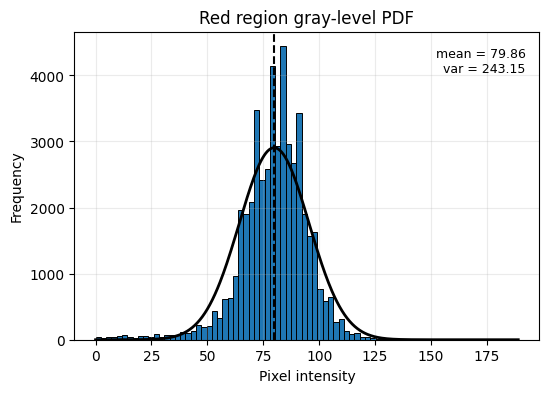

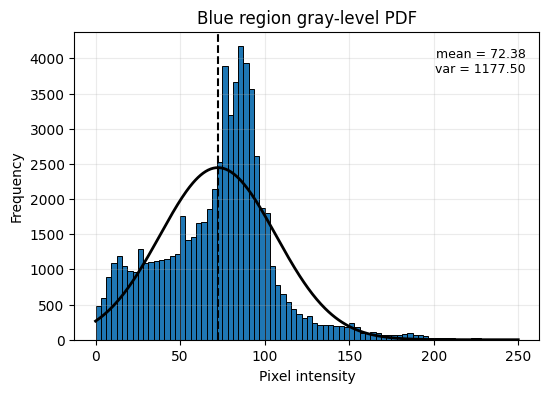

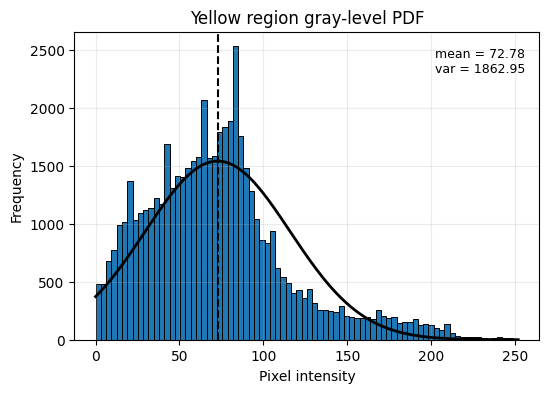

In [49]:
# plotting the grayscale histogram and Gaussian fit for the red patch
plot_gray_hist_with_gaussian(patch_red_gray, *params_red_gray, "Red region gray-level PDF")
# plotting the grayscale histogram and Gaussian fit for the blue patch
plot_gray_hist_with_gaussian(patch_blue_gray, *params_blue_gray, "Blue region gray-level PDF")
# plotting the grayscale histogram and Gaussian fit for the yellow patch
plot_gray_hist_with_gaussian(patch_yel_gray, *params_yel_gray, "Yellow region gray-level PDF")

# 13. KL divergence between 1D Gaussian distributions
A function that computes the closed-form KL divergence between two univariate Gaussian models, using their means and variances.

In [50]:
# computing the KL divergence between two 1D Gaussian distributions
def kl_divergence_gaussian(mu1, var1, mu2, var2):
    # applying the closed-form KL formula for univariate Gaussians
    kl = 0.5 * (np.log(var2 / var1) + (var1 + (mu1 - mu2) ** 2) / var2 - 1.0)
    return kl

# 14. Homogeneity decision using KL divergence
A function that compares every pair of grayscale Gaussian models using symmetric KL divergence. If the average KL is below a chosen threshold, the regions are considered homogeneous; otherwise, they are treated as different.

In [51]:
# deciding homogeneity between pairs of grayscale Gaussian models
def decide_homogeneity(params_list, threshold=0.5):
    # dictionary to store KL results and the final decision
    decisions = {}
    # labels assigned to the three patches
    labels = ["Red", "Blue", "Yellow"]
    # looping over all unique pairs of regions
    for i in range(len(params_list)):
        for j in range(i + 1, len(params_list)):
            # extracting mean and variance for each Gaussian
            mu1, var1 = params_list[i]
            mu2, var2 = params_list[j]
            # computing KL divergence in both directions
            kl12 = kl_divergence_gaussian(mu1, var1, mu2, var2)
            kl21 = kl_divergence_gaussian(mu2, var2, mu1, var1)
            # averaging the two KL values
            avg_kl = (kl12 + kl21) / 2.0
            # deciding homogeneity based on threshold
            hom = "homogeneous" if avg_kl < threshold else "non-homogeneous"
            # saving the result
            decisions[f"{labels[i]}-{labels[j]}"] = {"KL_avg": avg_kl, "decision": hom}
    return decisions

# 15. Printing grayscale homogeneity decisions
In this cell I'm computing and printing the KL-based homogeneity decisions between each pair of grayscale regions, showing whether they are statistically similar or different based on the threshold.

In [52]:
# computing KL-based homogeneity decisions between grayscale Gaussian models
decisions_gray = decide_homogeneity(params_list_gray)
# printing the decision results
print("Homogeneity decision (grayscale):")
for pair, info in decisions_gray.items():
    print(f"{pair}: {info['decision']} (KL = {info['KL_avg']:.3f})")

Homogeneity decision (grayscale):
Red-Blue: non-homogeneous (KL = 0.832)
Red-Yellow: non-homogeneous (KL = 1.506)
Blue-Yellow: homogeneous (KL = 0.054)


# 16. Displaying the full grayscale image

(-0.5, 803.5, 1412.5, -0.5)

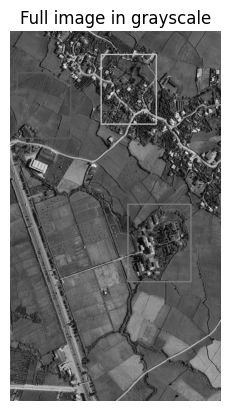

In [53]:
# creating a new figure for displaying the grayscale image
plt.figure()
# showing the full grayscale image
plt.imshow(img_full_gray, cmap="gray")
# setting the title of the plot
plt.title("Full image in grayscale")
# hiding axis ticks and labels
plt.axis("off")

# 17. Visualizing RGB & grayscale patches + classification result

(-0.5, 803.5, 1412.5, -0.5)

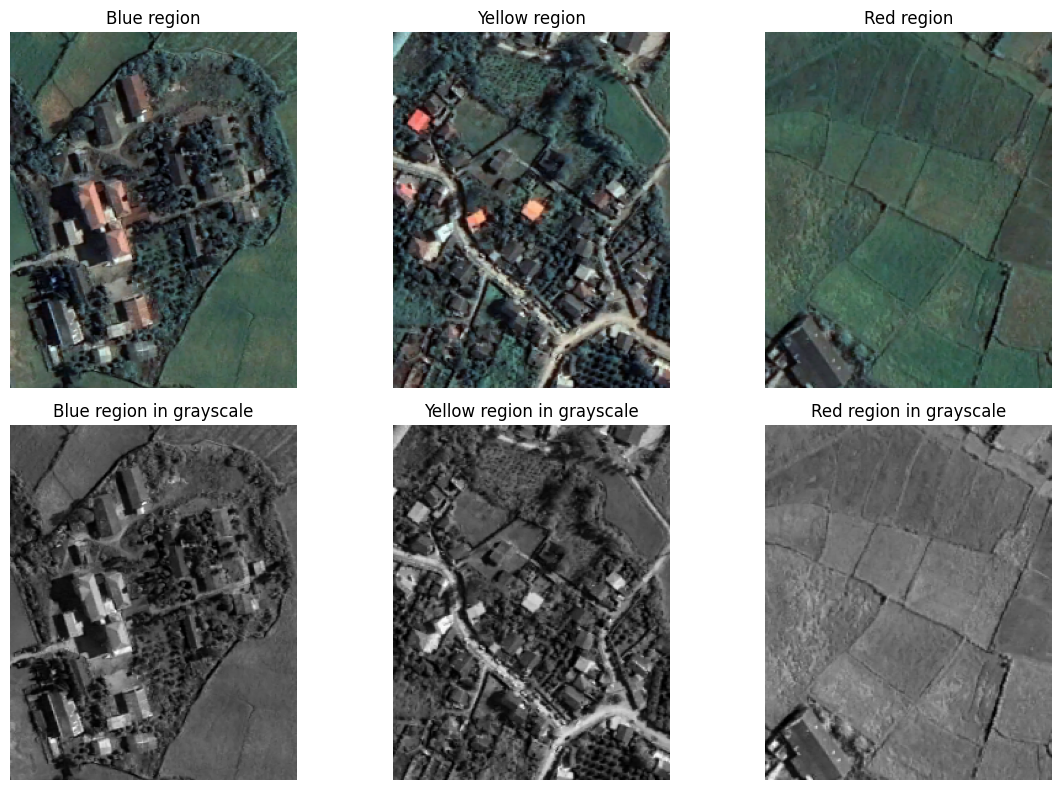

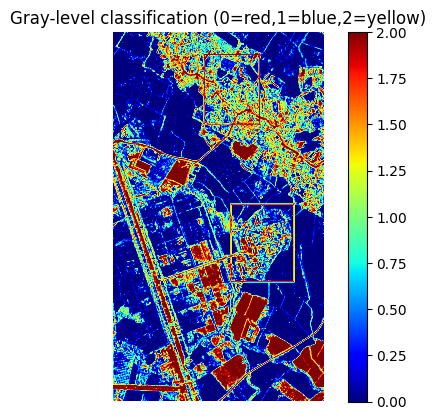

In [54]:
# creating a figure with subplots to show RGB and grayscale patches
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
# showing the blue patch (RGB)
axes[0, 0].imshow(np.array(patch_blue))
axes[0, 0].set_title("Blue region")
axes[0, 0].axis("off")
# showing the yellow patch (RGB)
axes[0, 1].imshow(np.array(patch_yellow))
axes[0, 1].set_title("Yellow region")
axes[0, 1].axis("off")
# showing the red patch (RGB)
axes[0, 2].imshow(np.array(patch_red))
axes[0, 2].set_title("Red region")
axes[0, 2].axis("off")
# showing the blue patch in grayscale
axes[1, 0].imshow(patch_blue_gray, cmap="gray")
axes[1, 0].set_title("Blue region in grayscale")
axes[1, 0].axis("off")
# showing the yellow patch in grayscale
axes[1, 1].imshow(patch_yel_gray, cmap="gray")
axes[1, 1].set_title("Yellow region in grayscale")
axes[1, 1].axis("off")
# showing the red patch in grayscale
axes[1, 2].imshow(patch_red_gray, cmap="gray")
axes[1, 2].set_title("Red region in grayscale")
axes[1, 2].axis("off")
# adjusting spacing between subplots
plt.tight_layout()
# creating a new figure for the classification result
plt.figure()
plt.imshow(labels_gray, cmap="jet")
plt.title("Gray-level classification (0=red,1=blue,2=yellow)")
plt.colorbar()
plt.axis("off")

# 18. Computing RGB Gaussian parameters

In [55]:
# computing mean vector and covariance matrix for an RGB patch
def gaussian_params_rgb(patch_rgb):
    # reshaping to N×3 so each row is an RGB pixel
    x = patch_rgb.reshape(-1, 3)
    # computing the mean of RGB channels
    mu = np.mean(x, axis=0)
    # computing the 3×3 covariance matrix (unbiased)
    sigma = np.cov(x, rowvar=False)
    return mu, sigma
# converting the full image to RGB and storing it as a float32 numpy array
img_full_rgb = np.array(img_full.convert("RGB"), dtype=np.float32)
# converting the red patch to RGB and storing it as a float32 numpy array
patch_red_rgb = np.array(patch_red.convert("RGB"), dtype=np.float32)
# converting the blue patch to RGB and storing it as a float32 numpy array
patch_blue_rgb = np.array(patch_blue.convert("RGB"), dtype=np.float32)
# converting the yellow patch to RGB and storing it as a float32 numpy array
patch_yel_rgb = np.array(patch_yellow.convert("RGB"), dtype=np.float32)
# computing the RGB Gaussian parameters for the red patch
params_red_rgb = gaussian_params_rgb(patch_red_rgb)
# computing the RGB Gaussian parameters for the blue patch
params_blue_rgb = gaussian_params_rgb(patch_blue_rgb)
# computing the RGB Gaussian parameters for the yellow patch
params_yellow_rgb = gaussian_params_rgb(patch_yel_rgb)
# grouping the RGB Gaussian parameters into a list
params_list_rgb = [params_red_rgb, params_blue_rgb, params_yellow_rgb]

# 19. Printing RGB Gaussian parameters

In [56]:
# printing the Gaussian parameters (mean and covariance) for the RGB patches
print("RGB Gaussian parameters:")
# iterating over each region and showing its mean vector + covariance matrix
for name, (mu, sigma) in [
    ("Red", params_red_rgb),
    ("Blue", params_blue_rgb),
    ("Yellow", params_yellow_rgb),
]:
    # printing means for the RGB channels
    print(f"{name}: mu = [{mu[0]:.3f}, {mu[1]:.3f}, {mu[2]:.3f}]")
    # printing the covariance matrix
    print(sigma)

RGB Gaussian parameters:
Red: mu = [65.703, 87.605, 77.199]
[[221.53612629 212.2181253  186.9168371 ]
 [212.2181253  294.82483824 236.40109694]
 [186.9168371  236.40109694 214.29535225]]
Blue: mu = [65.277, 76.079, 71.972]
[[1209.89135262 1144.72034064 1034.11390694]
 [1144.72034064 1259.53088989 1116.75929734]
 [1034.11390694 1116.75929734 1040.51916846]]
Yellow: mu = [67.551, 75.120, 74.472]
[[1953.31980013 1831.09318563 1707.0694822 ]
 [1831.09318563 1926.92894785 1811.07962637]
 [1707.0694822  1811.07962637 1739.0575548 ]]


# 20. Log-PDF for multivariate Gaussian (RGB)
A function that computes the log-probability of an RGB pixel under a multivariate Gaussian model using its mean vector and covariance matrix. This will later be used for RGB-based image classification.

In [57]:
# computing the log-pdf of a multivariate Gaussian distribution
def log_multivariate_gaussian(x, mu, sigma):
    # creating a multivariate normal object with the given mean and covariance
    rv = multivariate_normal(mean=mu, cov=sigma, allow_singular=False)
    # returning the log-probability density for input x
    return rv.logpdf(x)

# 21. RGB image classification using multivariate Gaussians
In this cell I'm defining the function that labels each RGB pixel according to which multivariate Gaussian model gives it the highest log-likelihood. The output is a 2D map of class labels for the entire image.

In [58]:
# classifying each RGB pixel using multivariate Gaussian log-likelihoods
def classify_rgb_image(img_rgb, params_list):
    # extracting height and width of the image
    h, w, _ = img_rgb.shape
    # reshaping the RGB image into N×3 form (each row is a pixel vector)
    x = img_rgb.reshape(-1, 3)
    # list to store log-likelihoods for each Gaussian model
    loglik = []
    # computing log-likelihood under each (mu, sigma) Gaussian model
    for mu, sigma in params_list:
        loglik.append(log_multivariate_gaussian(x, mu, sigma))
    # stacking results into a matrix of shape (num_classes × num_pixels)
    loglik = np.vstack(loglik)
    # selecting the class with highest log-likelihood per pixel
    labels = np.argmax(loglik, axis=0)
    # reshaping classification back to image dimensions
    return labels.reshape(h, w)

# 22. KL divergence for multivariate Gaussian distributions
I'm defining the closed-form KL divergence formula for two multivariate Gaussian models using their mean vectors and covariance matrices. This will later be used to evaluate similarity/homogeneity between RGB regions.

In [59]:
# computing KL divergence between two multivariate Gaussian distributions
def kl_divergence_multivariate(mu1, sigma1, mu2, sigma2):
    # dimensionality of the Gaussian (RGB → d = 3)
    d = len(mu1)
    # inverse of the second covariance matrix
    sigma2_inv = inv(sigma2)
    # difference between mean vectors
    diff_mu = mu2 - mu1
    # log(det Σ2 / det Σ1) term
    term1 = np.log(det(sigma2) / det(sigma1))
    # trace( Σ2^{-1} Σ1 ) term
    term2 = np.trace(sigma2_inv @ sigma1)
    # quadratic form (μ2 - μ1)^T Σ2^{-1} (μ2 - μ1)
    term3 = diff_mu.T @ sigma2_inv @ diff_mu
    # final KL divergence formula
    kl = 0.5 * (term1 + term2 + term3 - d)
    return kl

# 23. Homogeneity decision for multivariate Gaussians
A function that compares RGB Gaussian models using symmetric KL divergence. If the average KL is below a chosen threshold, the two regions are treated as homogeneous; otherwise, they are considered different.

In [60]:
# deciding homogeneity between RGB Gaussian models using symmetric KL divergence
def decide_homogeneity_multivariate(params_list, threshold=1.0):
    # dictionary for storing results
    decisions = {}
    # names for each region
    labels = ["Red", "Blue", "Yellow"]
    # looping over all unique pairs
    for i in range(len(params_list)):
        for j in range(i + 1, len(params_list)):
            # unpacking Gaussian parameters (mean + covariance)
            mu1, sigma1 = params_list[i]
            mu2, sigma2 = params_list[j]
            # computing KL divergence in both directions
            kl12 = kl_divergence_multivariate(mu1, sigma1, mu2, sigma2)
            kl21 = kl_divergence_multivariate(mu2, sigma2, mu1, sigma1)
            # symmetric KL divergence
            avg_kl = (kl12 + kl21) / 2.0
            # deciding homogeneity based on threshold
            hom = "homogeneous" if avg_kl < threshold else "non-homogeneous"
            # storing result
            decisions[f"{labels[i]}-{labels[j]}"] = {"KL_avg": avg_kl, "decision": hom}
    return decisions

# 24. RGB classification + homogeneity decisions

In [61]:
# classifying the full RGB image using multivariate Gaussian models
labels_color = classify_rgb_image(img_full_rgb, params_list_rgb)
# computing KL-based homogeneity decisions for RGB Gaussian parameters
decisions_rgb = decide_homogeneity_multivariate(params_list_rgb)
# printing the homogeneity results
print("Homogeneity decision (RGB):")
for pair, info in decisions_rgb.items():
    print(f"{pair}: {info['decision']} (KL = {info['KL_avg']:.3f})")

Homogeneity decision (RGB):
Red-Blue: non-homogeneous (KL = 1.927)
Red-Yellow: non-homogeneous (KL = 4.236)
Blue-Yellow: homogeneous (KL = 0.376)


# 25. RGB histogram plotting
I'm defining a function to plot separate histograms for the R, G, and B channels of a color patch. Each plot includes a dashed vertical line showing the mean value of that channel.

In [62]:
# plotting RGB histograms for each channel with mean lines
def plot_rgb_hist(patch_rgb, mu, title):
    # creating a row of 3 subplots for R, G, B histograms
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    # list of channel names
    channels = ["R", "G", "B"]
    # reshaping into N×3 so each row is one RGB pixel
    x = patch_rgb.reshape(-1, 3)
    # plotting histogram for each RGB channel
    for i, ch in enumerate(channels):
        axes[i].hist(
            x[:, i],
            bins=50,
            density=True,
            alpha=0.7,
            edgecolor="black",
            linewidth=0.8
        )
        # vertical line at channel mean
        axes[i].axvline(mu[i], linestyle="--", linewidth=1.2)
        # titles and labels
        axes[i].set_title(f"{title} - {ch}")
        axes[i].set_xlabel("Intensity")
    # adjusting layout
    plt.tight_layout()
    plt.show()

# 26. Visualizing RGB histograms for all patches

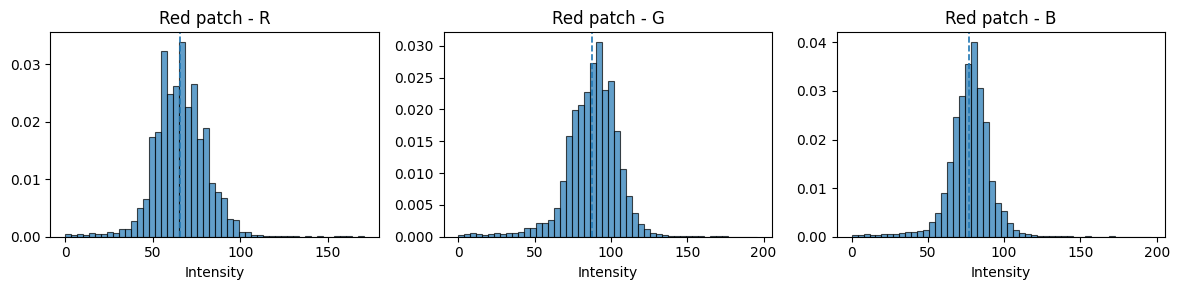

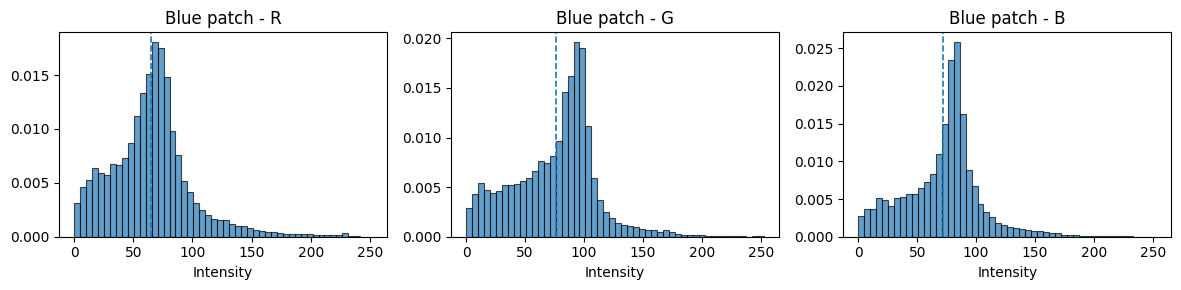

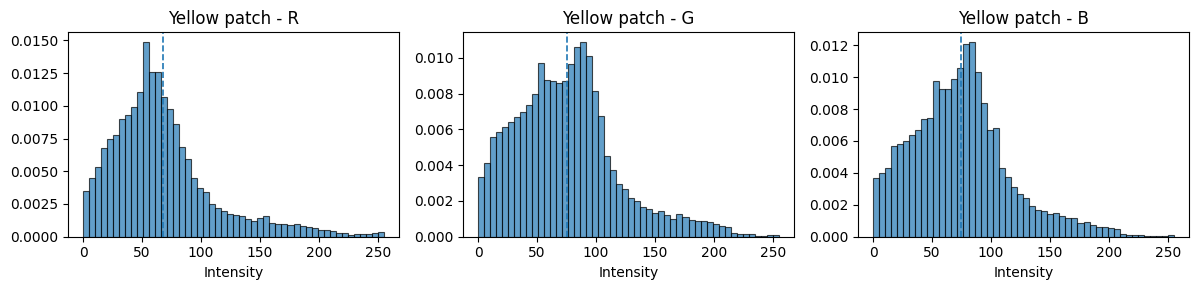

In [63]:
# plotting RGB histograms for the red patch
plot_rgb_hist(patch_red_rgb, params_red_rgb[0], "Red patch")
# plotting RGB histograms for the blue patch
plot_rgb_hist(patch_blue_rgb, params_blue_rgb[0], "Blue patch")
# plotting RGB histograms for the yellow patch
plot_rgb_hist(patch_yel_rgb, params_yellow_rgb[0], "Yellow patch")

# 27. Displaying RGB image and its classification result

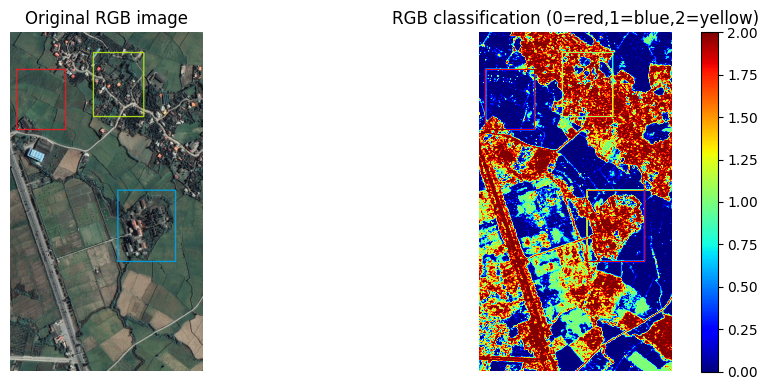

In [64]:
# creating a figure to show original RGB image and its RGB-based classification
plt.figure(figsize=(10, 4))
# showing the original RGB image
plt.subplot(1, 2, 1)
plt.imshow(img_full_rgb.astype(np.uint8))
plt.title("Original RGB image")
plt.axis("off")
# showing the RGB classification result (label map)
plt.subplot(1, 2, 2)
plt.imshow(labels_color, cmap="jet")
plt.title("RGB classification (0=red,1=blue,2=yellow)")
plt.colorbar()
plt.axis("off")
# adjusting layout for cleaner spacing
plt.tight_layout()
plt.show()

# 28. Checking variance similarity using log-likelihood criterion
This function compares two regions based on the log-likelihood form used earlier.  
It checks whether the combined variance is close enough to individual variances using a tolerance threshold.

In [65]:
def check_similarity_log(n1, sigma1, n2, sigma2, sigma12, tolerance):
    # Small epsilon to avoid taking log(0) which would break the computation
    eps = 1e-8
    # Ensure variances are not zero or negative before applying log
    sigma1  = max(sigma1, eps)
    sigma2  = max(sigma2, eps)
    sigma12 = max(sigma12, eps)
    # Compute the log-likelihood delta value to assess similarity
    delta = (n1 + n2) * np.log(sigma12) - (n1 * np.log(sigma1) + n2 * np.log(sigma2))
    # Return True if the regions are considered similar under the given tolerance
    return delta < tolerance

# 29. Deciding variance homogeneity between gray patches (log-likelihood rule)
This section computes pairwise variance–similarity between gray-level patches using the same log-likelihood decision rule.  
Each pair of regions is flattened, their variances are computed, and the log-likelihood delta determines whether they should be considered similar (merge) or different.


In [66]:
def decide_homogeneity_variance_gray(patches_gray, tolerance=0.0):
    labels = ["Red", "Blue", "Yellow"]
    decisions = {}
    # Loop over all pairs of patches (Red-Blue, Red-Yellow, Blue-Yellow)
    for i in range(len(patches_gray)):
        for j in range(i + 1, len(patches_gray)):
            # Flatten patches to 1D and convert to float64 for stability
            x1 = patches_gray[i].reshape(-1).astype(np.float64)
            x2 = patches_gray[j].reshape(-1).astype(np.float64)
            # Concatenate the two patches to form the combined region
            x12 = np.concatenate([x1, x2])
            # Sample sizes
            n1, n2 = len(x1), len(x2)
            # Sample standard deviations (unbiased, ddof=1)
            sigma1  = np.std(x1, ddof=1)
            sigma2  = np.std(x2, ddof=1)
            sigma12 = np.std(x12, ddof=1)
            # Decide if the two regions are similar in variance using the log rule
            similar = check_similarity_log(n1, sigma1, n2, sigma2, sigma12, tolerance)
            # Build a readable key like "Red-Blue", "Red-Yellow", "Blue-Yellow"
            key = f"{labels[i]}-{labels[j]}"
            # I also store the delta explicitly here (with eps to avoid log(0))
            decisions[key] = {
                "sigma1": sigma1,
                "sigma2": sigma2,
                "sigma_combined": sigma12,
                "delta": (n1 + n2) * np.log(max(sigma12, 1e-8)) - (
                    n1 * np.log(max(sigma1, 1e-8)) + n2 * np.log(max(sigma2, 1e-8))
                ),
                "decision": "similar (merge)" if similar else "different (no merge)",
            }
    return decisions

# 30. Plotting gray-level histogram with variance-based Gaussian fit
This cell plots the histogram of a grayscale patch and overlays a Gaussian curve whose parameters  
(mean and variance) are computed directly from the patch.  


In [67]:
def plot_gray_hist_variance(patch_gray, title):
    # Flatten patch and convert to float for numerical safety
    x = patch_gray.reshape(-1).astype(float)
    # Compute mean, variance (unbiased), and corresponding standard deviation
    mu = np.mean(x)
    var = np.var(x, ddof=1)
    sigma = np.sqrt(var)
    # Create figure and axis for plotting
    fig, ax = plt.subplots(figsize=(6, 4))
    # Plot histogram with same style as Gaussian version
    counts, bins, patches = ax.hist(
        x,
        bins=80,
        density=False,
        edgecolor="black",
        linewidth=0.7
    )
    # Bin width is needed for scaling the Gaussian curve properly
    bin_width = bins[1] - bins[0]
    # Create Gaussian curve using variance-based parameters
    xs = np.linspace(bins[0], bins[-1], 500)
    pdf = (1.0 / (np.sqrt(2.0 * np.pi) * sigma)) * np.exp(-(xs - mu) ** 2 / (2.0 * var))
    # Scale PDF so it overlays properly on histogram counts
    pdf_scaled = pdf * len(x) * bin_width
    ax.plot(xs, pdf_scaled, linewidth=2.0, color="black")
    # Draw dashed vertical line at the mean
    ax.axvline(mu, linestyle="--", linewidth=1.5, color="black")
    # Axis labels and title
    ax.set_title(title + " (Variance-based)")
    ax.set_xlabel("Pixel intensity")
    ax.set_ylabel("Frequency")
    # Add a light grid for readability
    ax.grid(True, alpha=0.25)
    # Display mean and variance inside a small text box (top-right corner)
    text = f"mean = {mu:.2f}\nvar = {var:.2f}"
    ax.text(
        0.97, 0.95, text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9
    )

# 31. Plotting variance-based histograms for red, blue, and yellow gray patches

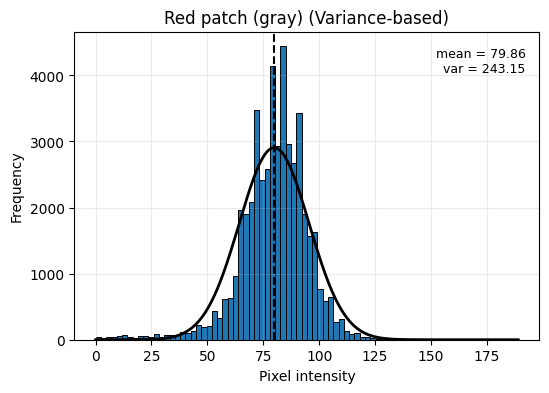

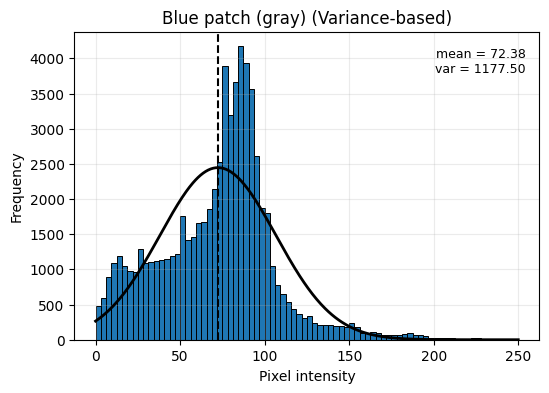

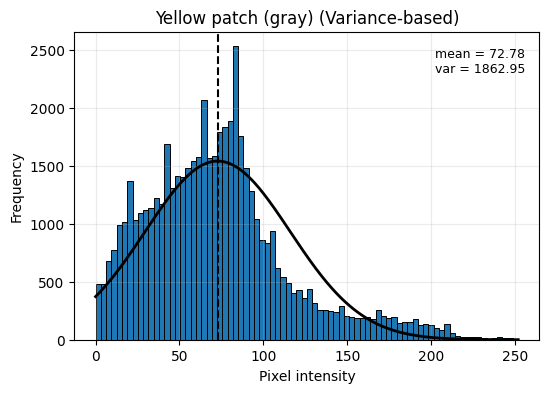

In [68]:
# Plot histogram + variance-based Gaussian fit for the red patch in grayscale
plot_gray_hist_variance(patch_red_gray,  "Red patch (gray)")
# Plot histogram + variance-based Gaussian fit for the blue patch in grayscale
plot_gray_hist_variance(patch_blue_gray, "Blue patch (gray)")
# Plot histogram + variance-based Gaussian fit for the yellow patch in grayscale
plot_gray_hist_variance(patch_yel_gray,  "Yellow patch (gray)")

# 32. Plotting RGB histograms with variance-based statistics
This function plots separate histograms for the R, G, and B channels of an RGB patch.    


In [69]:
def plot_rgb_hist_variance(patch_rgb, title):
    # Create a row of 3 subplots, one for each color channel
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    channels = ["R", "G", "B"]
    # Reshape patch into Nx3 and convert to float for stable variance calculations
    x = patch_rgb.reshape(-1, 3).astype(float)
    # Loop through each channel index + label
    for i, ch in enumerate(channels):
        # Extract the values for the current channel
        ch_vals = x[:, i]
        # Compute sample mean and unbiased variance for the channel
        mu = np.mean(ch_vals)
        var = np.var(ch_vals, ddof=1)
        # Plot histogram of pixel intensities for this channel
        axes[i].hist(
            ch_vals,
            bins=50,
            density=True,
            alpha=0.7,
            edgecolor="black",
            linewidth=0.8
        )
        # Add a dashed vertical line to indicate the mean intensity
        axes[i].axvline(mu, linestyle="--", linewidth=1.2, color="black")
        # Title indicating which channel and that this is variance-based
        axes[i].set_title(f"{title} - {ch} (Var-based)")
        axes[i].set_xlabel("Intensity")
        # Add a small text box showing the mean and variance
        text = f"mean = {mu:.1f}\nvar = {var:.1f}"
        axes[i].text(
            0.97, 0.95, text,
            transform=axes[i].transAxes,
            ha="right",
            va="top",
            fontsize=8
        )
    # Improve layout spacing and display the figure
    plt.tight_layout()
    plt.show()

# 33. Plotting variance-based RGB histograms for red, blue, and yellow patches

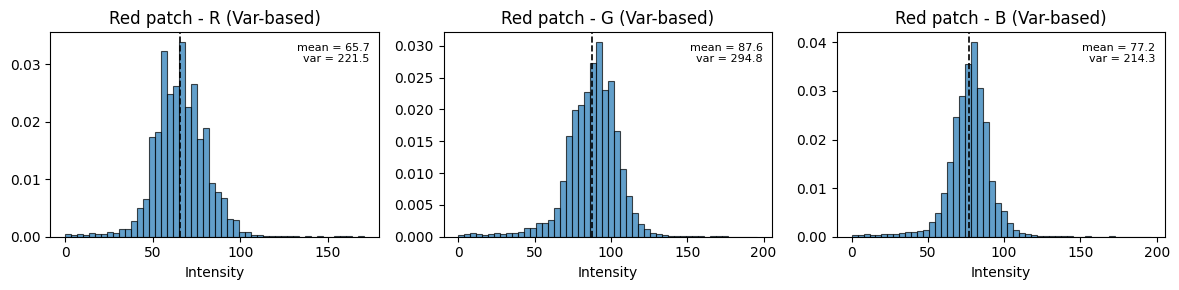

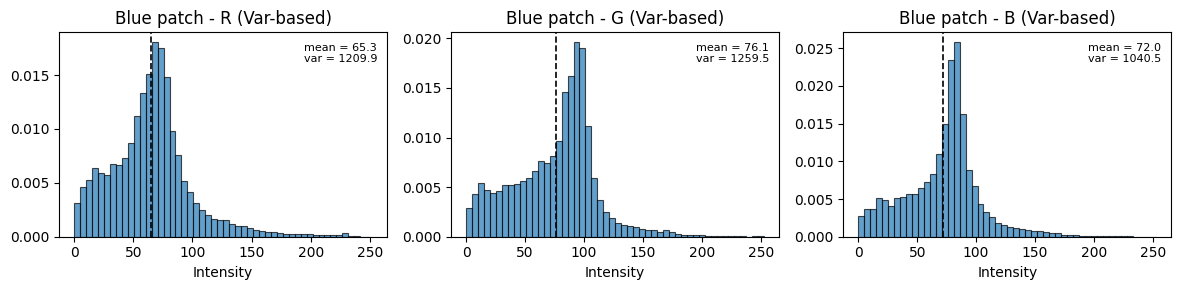

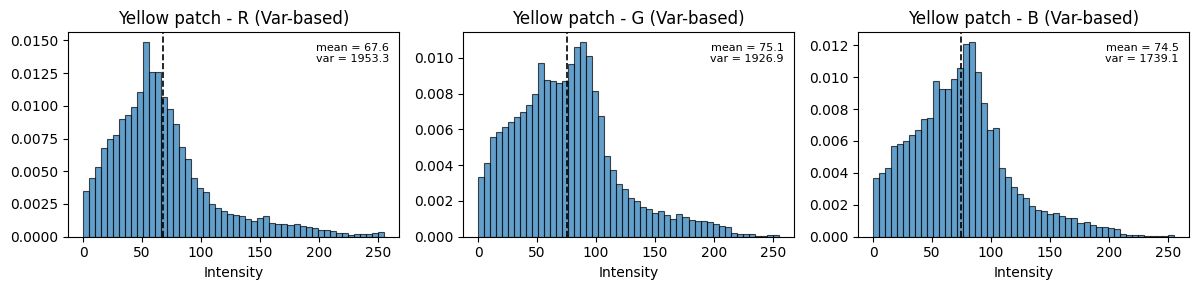

In [70]:
# Plot RGB histograms (variance-based) for the red patch
plot_rgb_hist_variance(patch_red_rgb,  "Red patch")
# Plot RGB histograms (variance-based) for the blue patch
plot_rgb_hist_variance(patch_blue_rgb, "Blue patch")
# Plot RGB histograms (variance-based) for the yellow patch
plot_rgb_hist_variance(patch_yel_rgb,  "Yellow patch")

# 34. RGB image classification using variance-only diagonal Gaussian model
This function classifies each pixel of an RGB image.

In [71]:
def classify_rgb_image_variance(img_rgb, params_list_rgb):
    # Extract image dimensions (height, width, 3 channels)
    h, w, _ = img_rgb.shape
    # Flatten image into N×3 matrix of pixel values
    X = img_rgb.reshape(-1, 3).astype(np.float64)
    # Store log-likelihood values for each class
    loglik_list = []
    # Loop through all class parameter sets (μ, Σ)
    for (mu, Sigma) in params_list_rgb:
        mu = np.asarray(mu, dtype=np.float64)
        Sigma = np.asarray(Sigma, dtype=np.float64)
        # Extract diagonal variances only (variance per channel)
        var = np.diag(Sigma).astype(np.float64).copy()
        # Prevent zero or negative variances from causing numerical issues
        var[var <= 0] = 1e-6
        # Compute class log-likelihood for all pixels
        term = -0.5 * (np.log(2.0 * np.pi * var) + ((X - mu) ** 2) / var)
        # Sum across channels to get total log-likelihood for each pixel
        loglik = np.sum(term, axis=1)
        loglik_list.append(loglik)
    # Stack log-likelihoods into shape (num_classes, N)
    loglik_all = np.vstack(loglik_list)
    # Classify each pixel by choosing the class with max log-likelihood
    labels = np.argmax(loglik_all, axis=0)
    # Reshape labels back to image dimensions
    return labels.reshape(h, w)

# 35. Applying variance-based RGB classification and visualizing the results

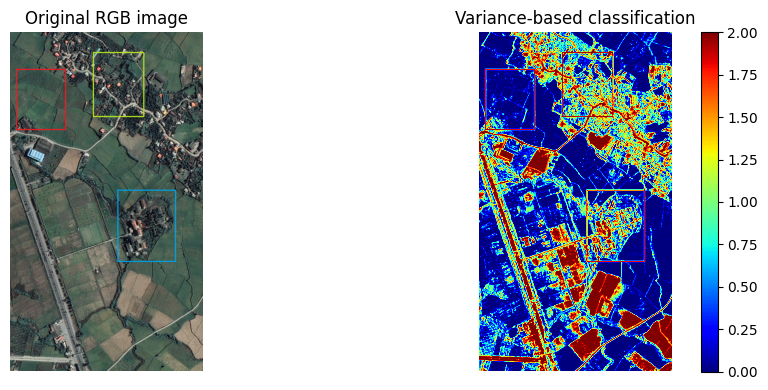

In [72]:
# Run variance-based RGB classification on the full image
labels_color_var = classify_rgb_image_variance(img_full_rgb, params_list_rgb)
# Create a figure with two side-by-side subplots
plt.figure(figsize=(10, 4))
# Original RGB image 
plt.subplot(1, 2, 1)
plt.imshow(img_full_rgb.astype(np.uint8))      
plt.title("Original RGB image")
plt.axis("off")                                
# Variance-based classification result
plt.subplot(1, 2, 2)
plt.imshow(labels_color_var, cmap="jet", vmin=0, vmax=2) 
plt.title("Variance-based classification")
plt.colorbar()                                        
plt.axis("off")
# Layout adjustment for nicer spacing
plt.tight_layout()
plt.show()

# 36. Deciding RGB region homogeneity using channel-wise log-variance rule
In this cell I compare every pair of RGB patches (Red, Blue, Yellow) using the same  
log-likelihood variance rule.

In [73]:
def decide_homogeneity_variance_rgb(patches_rgb, tolerance=0.0):
    labels = ["Red", "Blue", "Yellow"]
    channel_names = ["R", "G", "B"]
    decisions = {}
    # Loop over all unique pairs of RGB patches (Red-Blue, Red-Yellow, Blue-Yellow)
    for i in range(len(patches_rgb)):
        for j in range(i + 1, len(patches_rgb)):
            # Flatten both patches to N×3 and cast to float for stability
            p1 = patches_rgb[i].reshape(-1, 3).astype(np.float64)
            p2 = patches_rgb[j].reshape(-1, 3).astype(np.float64)
            # Concatenate them along the sample axis
            p12 = np.concatenate([p1, p2], axis=0)
            # Number of pixels in each patch
            n1, n2 = len(p1), len(p2)
            channels_info = []
            all_similar = True  # will turn False if any channel is not similar
            # Go over R, G, B channels separately
            for ch in range(3):
                # Extract current channel values from each patch and from the merged one
                v1  = p1[:, ch]
                v2  = p2[:, ch]
                v12 = p12[:, ch]
                # Sample standard deviations (unbiased)
                sigma1  = np.std(v1, ddof=1)
                sigma2  = np.std(v2, ddof=1)
                sigma12 = np.std(v12, ddof=1)
                # Decide similarity using the log-likelihood-based rule
                similar = check_similarity_log(n1, sigma1, n2, sigma2, sigma12, tolerance)
                if not similar:
                    all_similar = False  # at least one channel disagrees
                # I also compute and store the delta explicitly here
                delta = (n1 + n2) * np.log(max(sigma12, 1e-8)) - (
                    n1 * np.log(max(sigma1, 1e-8)) + n2 * np.log(max(sigma2, 1e-8))
                )
                channels_info.append({
                    "channel": channel_names[ch],
                    "sigma1": sigma1,
                    "sigma2": sigma2,
                    "sigma_combined": sigma12,
                    "delta": delta,
                    "similar": similar,
                })
            # Key like "Red-Blue", "Red-Yellow", or "Blue-Yellow"
            key = f"{labels[i]}-{labels[j]}"
            # Overall decision depends on all three channels
            decisions[key] = {
                "decision": "similar (merge)" if all_similar else "different (no merge)",
                "channels": channels_info,
            }
    return decisions

#  37. Comparing Gaussian-based vs variance-based RGB classification

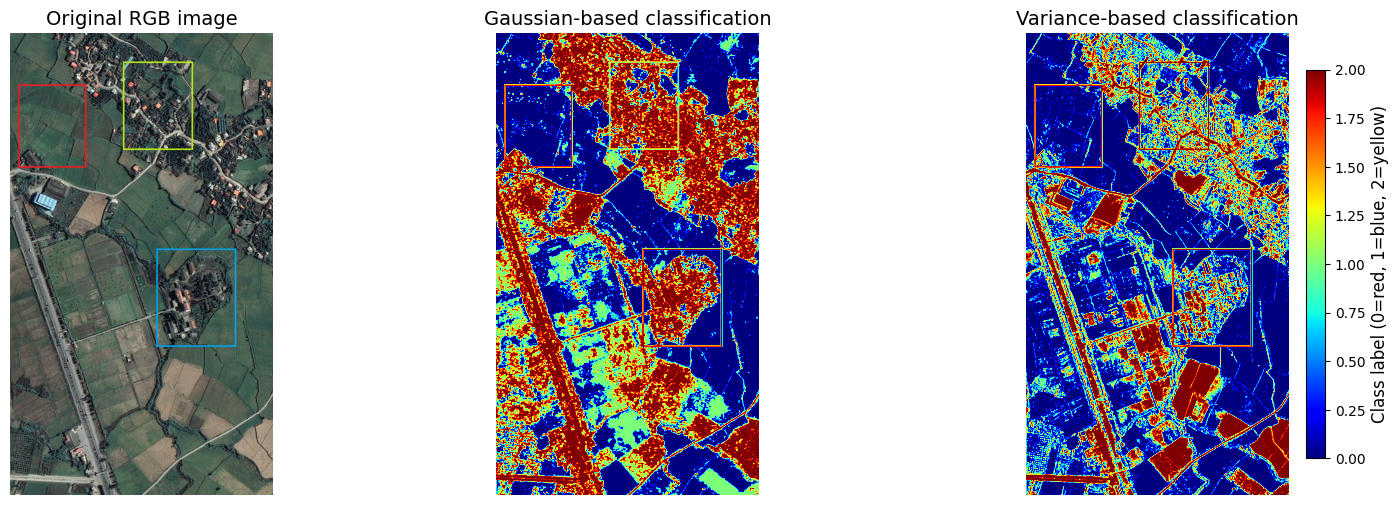

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Original image
axes[0].imshow(img_full_rgb.astype(np.uint8))
axes[0].set_title("Original RGB image", fontsize=14)
axes[0].axis("off")
# Gaussian classification
im1 = axes[1].imshow(labels_color, cmap="jet", vmin=0, vmax=2)
axes[1].set_title("Gaussian-based classification", fontsize=14)
axes[1].axis("off")
# Variance classification
im2 = axes[2].imshow(labels_color_var, cmap="jet", vmin=0, vmax=2)
axes[2].set_title("Variance-based classification", fontsize=14)
axes[2].axis("off")
# Add a colorbar linked to the third classification image
cbar = fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_label("Class label (0=red, 1=blue, 2=yellow)", fontsize=12)
# Adjust horizontal spacing so subplots don’t overlap
plt.subplots_adjust(wspace=0.15)  
plt.show()